# Getting Started

## STLDriver object

An `STLDriver` object can 
- parse textual specifications, 
- store data as signals,
- monitor formulas returning satisfaction and robustness signals and,
- plot stuff. 

In [1]:
import stlrom as stl
d = stl.STLDriver()
d.parse_string('signal x,y')
print(d)

# STLDriver object defined as
signal x, y

# With formulas:
# No formula yet.

# Data:
# No data yet.



## Adding signal data

The simplest way to add data to a `STLDriver` object is using the method `add_sample`. By default, they are interpreted to define piecewise linear signals. 

In [2]:
d.add_sample([0, -0.4, 0.6]) # time, x, y
d.add_sample([0.5, 0.7, 0.1])
d.add_sample([1.1, -0.1, 0.7])
print(d)

# STLDriver object defined as
signal x, y

# With formulas:
# No formula yet.

# Data:
# Signal x:
# 3 samples from t0=0 to t_end=1.1
# Signal y:
# 3 samples from t0=0 to t_end=1.1




In [3]:
x = d.get_signal('x')
print(x)

begin_time: 0  end_time: 1.1
time:          0  value:       -0.4  derivative:        2.2
time:        0.5  value:        0.7  derivative:     -1.333
time:        1.1  value:       -0.1  derivative:          0



## First Plots

Using `plot_signal` or `plot_signals` we can plot the signals interpolated from the data. 

<Axes: xlabel='Time', ylabel='Value'>

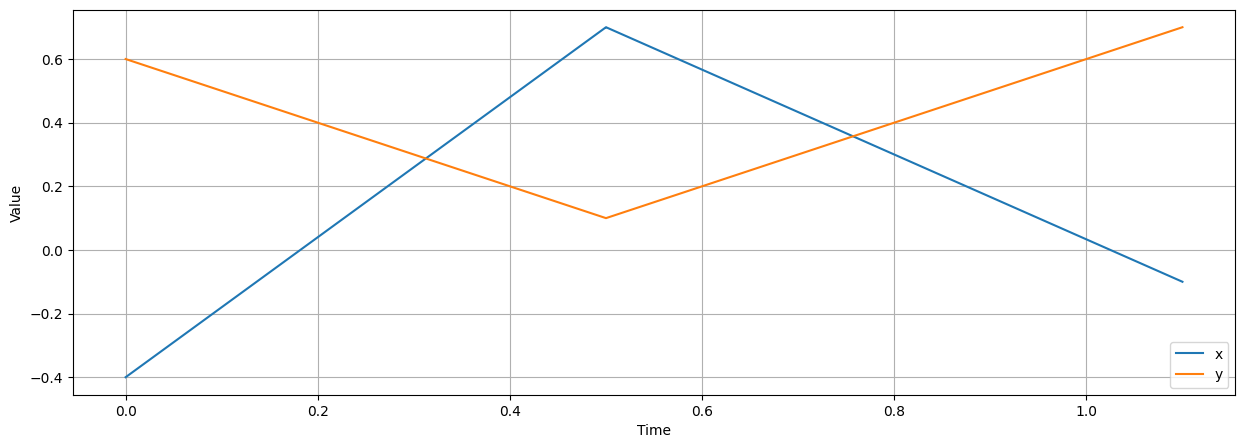

In [4]:
d.plot_signals(['x', 'y'])

<Axes: xlabel='Time', ylabel='Value'>

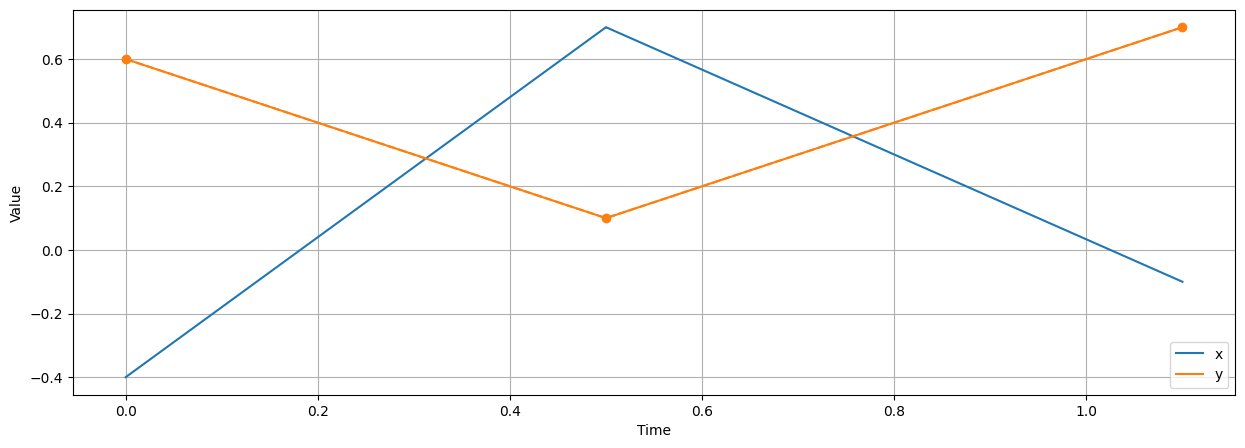

In [5]:
ax = d.plot_signal('x')
d.plot_signal('y', ax=ax, draw_samples=True) # show samples as dots, plot on same as as 'x'


## First Predicates

In [6]:
d.parse_string("""
mu_x    := x[t]>0
mu_y    := y[t]>.5
mu_comp := x[t]<y[t]
""")
print(d)

# STLDriver object defined as
signal x, y

# With formulas:
mu_comp:= x[t] < y[t]
mu_x:= x[t] > 0
mu_y:= y[t] > 0.5

# Data:
# Signal x:
# 3 samples from t0=0 to t_end=1.1
# Signal y:
# 3 samples from t0=0 to t_end=1.1




## Satisfaction Evaluation

### Boolean Satisfaction

In [7]:
d.set_semantics('BOOLEAN')
sat_mu = d.get_rob_signal('mu_x',0,1.1)
print(sat_mu)

begin_time: 0  end_time: 1.1
time:          0  value:          0  derivative:          0
time:     0.1818  value:          1  derivative:          0
time:      1.025  value:          0  derivative:          0



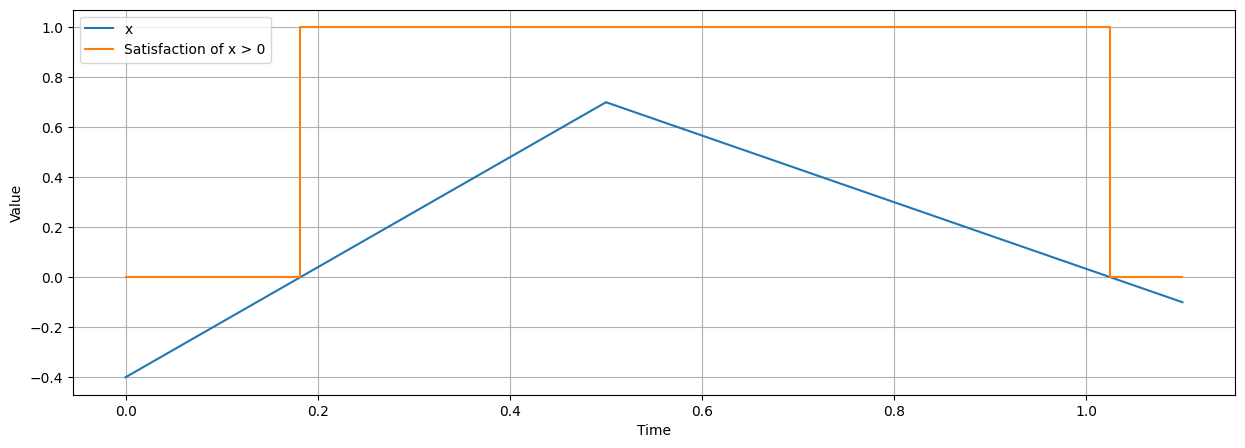

In [8]:
ax = d.plot_signal('x')  # plots signal x, returns axis
ax = sat_mu.plot(label='Satisfaction of x > 0', ax=ax)


### Robust Satisfaction

In [9]:
d.set_semantics('SPACE')
rob_mu_y = d.get_rob_signal('mu_y',0,1.1)
print(rob_mu_y)

begin_time: 0  end_time: 1.1
time:          0  value:        0.1  derivative:         -1
time:        0.1  value:     -1e-10  derivative:          0
time:        0.1  value:     -1e-10  derivative:         -1
time:        0.5  value:       -0.4  derivative:          1
time:        0.9  value:     -1e-10  derivative:          0
time:        0.9  value:      1e-10  derivative:          1
time:        1.1  value:        0.2  derivative:          0



In [ ]:
ax = d.plot_signal('y')  # plots signal x, returns axis
rob_mu_y.plot(label='Robustness of y > 2', ax=ax)


In [ ]:
ax = d.plot_signal('y')
rob_mu_y.plot(label='Robustness of y > 2', plot_sat=True,plot_rob=False, ax=ax)


# Signal Generation

`stlrom.signal_gen` provides a small library of signal generators. Their generic use is as follows:

- Create a signal generator object with `sig_gen= SomeSignalGen(param1= ..., param2=..., etc)`
- Get a concrete signal defined on  `[t0, tf]` with `sig= sig_gen.get_signal(t0,tf)`. Note that `t0` and `tf` are mandatory arguments.

### Piecewise Constant Signal 

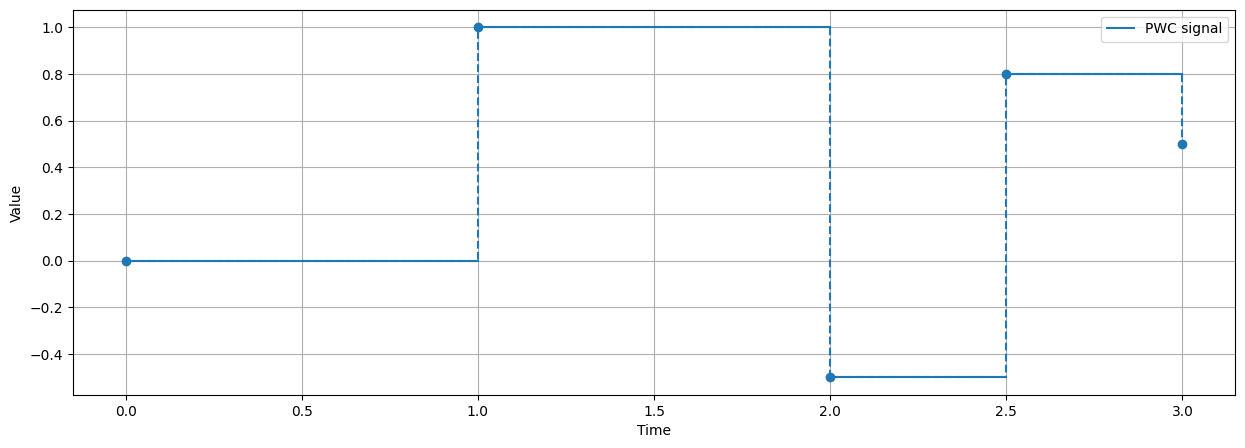

In [11]:
from stlrom.signal_gen import PWCSignalGen

pwc_gen = PWCSignalGen(times=[0, 1., 2., 2.5, 3.],
                       values=[0., 1., -0.5, 0.8, 0.5])
pwc_signal = pwc_gen.get_signal(t0=0,tf=3)
pwc_signal.plot(label='PWC signal', draw_samples=True);

### Piecewise Linear Signals

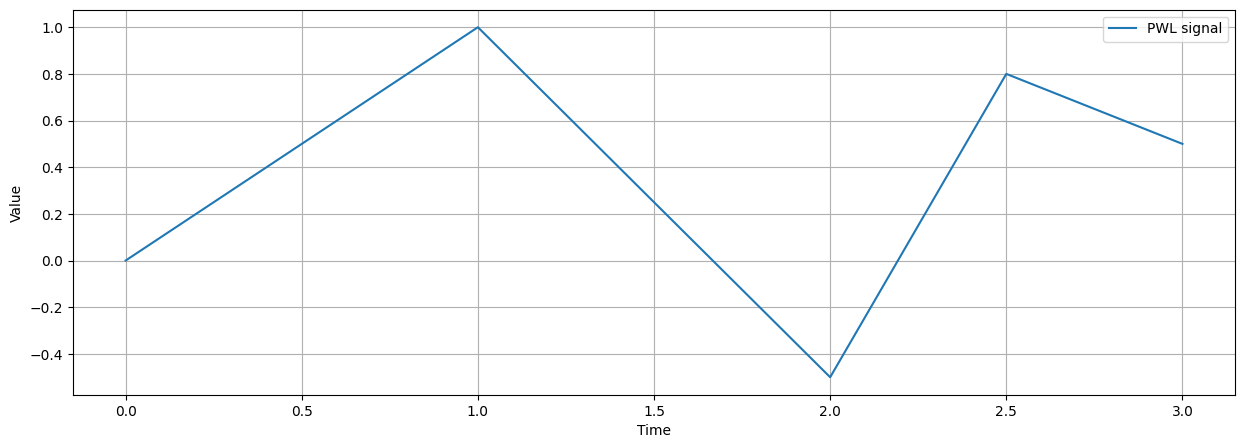

In [12]:
from stlrom import PWLSignalGen

pwl_gen = PWLSignalGen(times=[0, 1., 2., 2.5, 3.],
                       values=[0., 1., -0.5, 0.8, 0.5])
pwl_signal = pwl_gen.get_signal(0,3)
pwl_signal.plot(label='PWL signal');

### Oscillation Signals

Parameters: (`period,amplitude, base, damp`). Since these signals are not piecewise linear, we need to approximate them. We do it with a fixed time step `dt`. 

<Axes: xlabel='Time', ylabel='Value'>

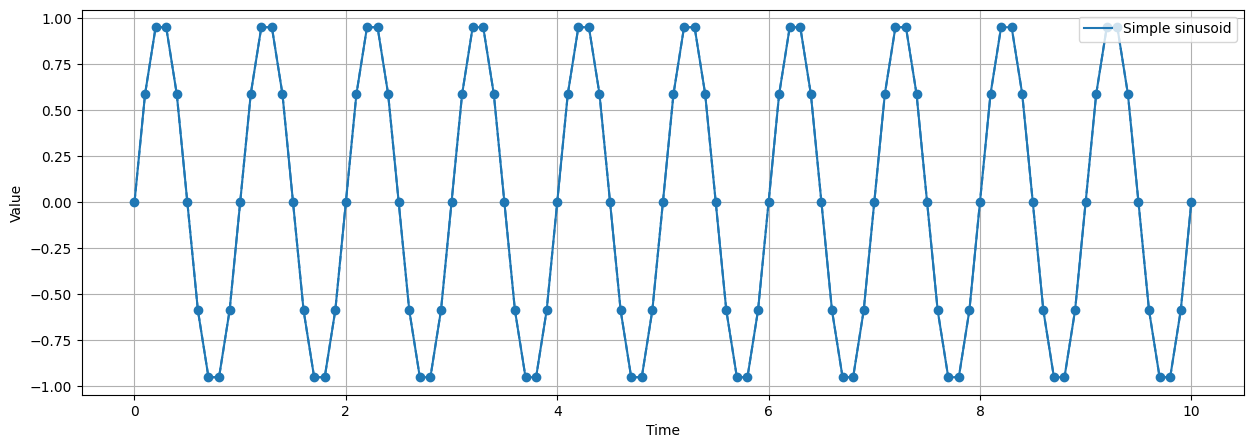

In [13]:
from stlrom import OscillSignalGen
osc_gen = OscillSignalGen()
x0  = osc_gen.get_signal(t0=0, tf=10, dt=0.1) # piecewise linear approximation with dt=0.1
x0.plot(label='Simple sinusoid', draw_samples=True)

(<Axes: xlabel='Time', ylabel='Value'>, <Axes: xlabel='Time', ylabel='Value'>)

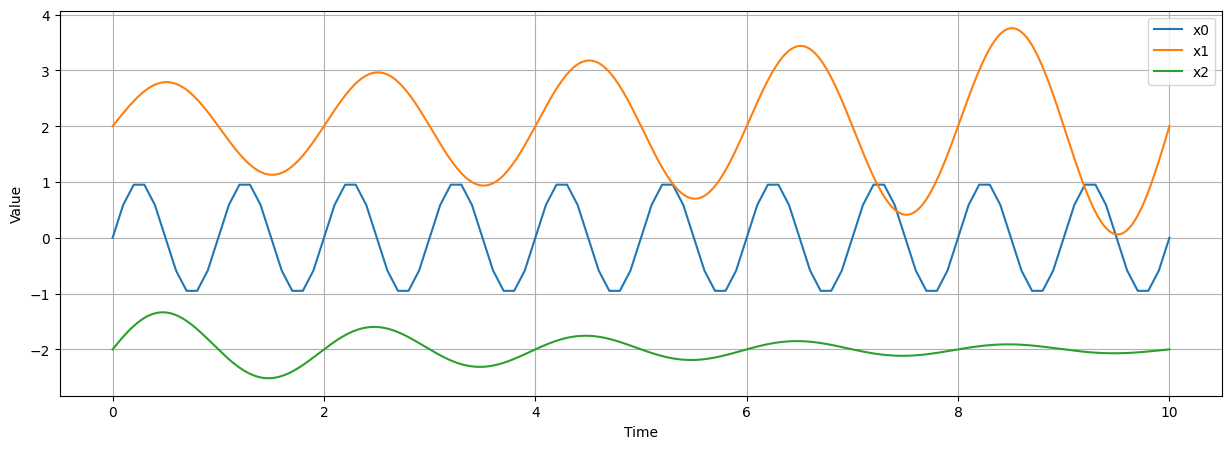

In [14]:
x1= osc_gen.set_param(period=2, base=2 , amplitude=0.75, damp=0.1  ).get_signal(0,10, dt=0.02) #increasing oscillations
x2= osc_gen.set_param(period=2, base=-2, amplitude=0.75, damp=-0.25).get_signal(0,10, dt=0.02) # decreasing oscillations
ax = x0.plot('x0')
x1.plot('x1', ax=ax), x2.plot('x2', ax=ax) # plotting 

### Random Signals

Parameters: (`seed, v_min, v_max, dv_max, dt_min,dt_max, interp`). 

In [15]:
from stlrom import RandSignalGen

v_min=-5
v_max=5
dv_max=1
dt_min=0.1
dt_max=0.2

rand_sg_pwc = RandSignalGen(v_min=v_min, v_max=v_max, dv_max=dv_max, dt_min=dt_min, dt_max=dt_max)
rand_sg_pwl = RandSignalGen(dv_max=dv_max, dt_min=dt_min, dt_max=dt_max, interp='LINEAR')



<Axes: xlabel='Time', ylabel='Value'>

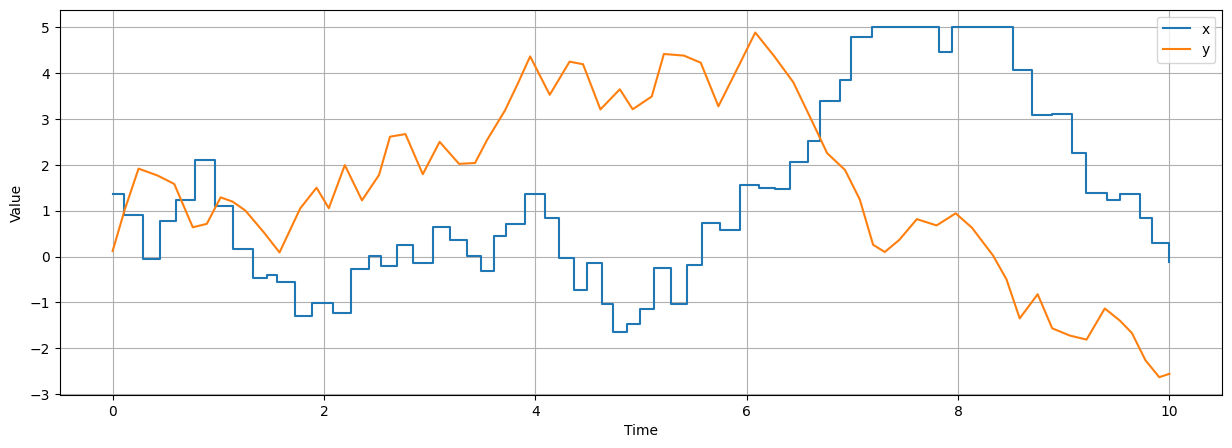

In [16]:
x_rand=rand_sg_pwc.set_param(seed=0).get_signal(0,10)
y_rand=rand_sg_pwl.set_param(seed=1).get_signal(0,10)

ax= x_rand.plot('x')
y_rand.plot('y', ax=ax)

# Temporal Operators

## Temperature Example
Here we create a synthetic signal mimicking temperature measurements. 

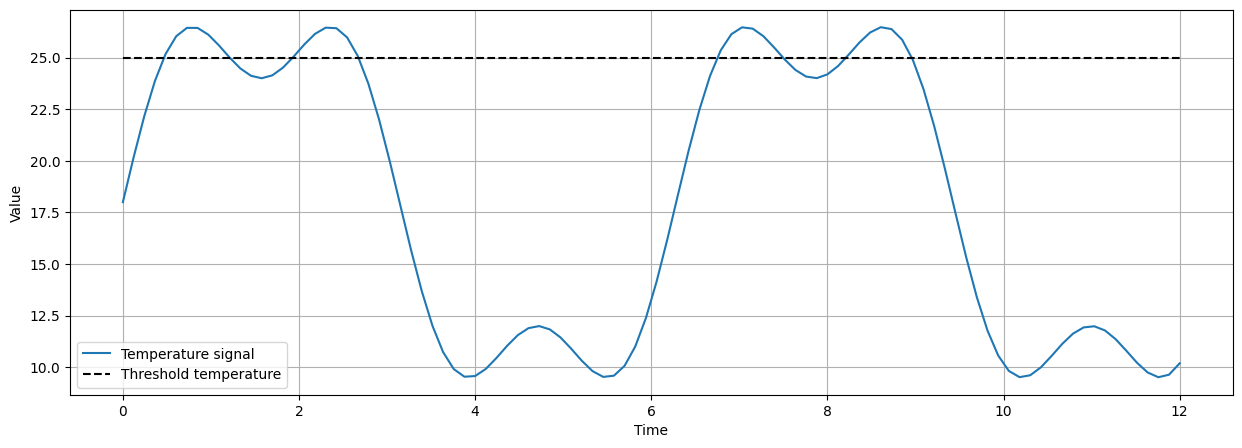

In [17]:
import numpy as np
times = np.linspace(0, 12, 100)
values = 18 + 9 * np.sin(times) + 3 * np.sin(3 * times)
temp_signal = PWLSignalGen(times = times, values = values).get_signal(0,12)

ax = temp_signal.plot(label='Temperature signal');
ax.plot([0, temp_signal.end_time], [25, 25], linestyle='--', color='black', label="Threshold temperature");
ax.legend();


We define some specifications:

In [20]:
Temperature_specs = """
signal temp
param hot = 25, cool=11

temp_is_hot := temp[t]  > hot
temp_is_cool := temp[t] < cool

param tau=1
alw_hot := alw_[0, tau] temp_is_hot # Hot during tau time units

param tau_cool = 2
ev_cool := ev[0, tau_cool] temp_is_cool

# If temperature is above hot, it should eventually be cool within tau_cool seconds
param Tf = 8
phi := alw[0, Tf] (temp_is_hot => ev_cool)
    
"""

In [21]:
Dtemp = stl.STLDriver()
Dtemp.parse_string(Temperature_specs)
Dtemp.set_signals([temp_signal])

<Axes: xlabel='Time', ylabel='Value'>

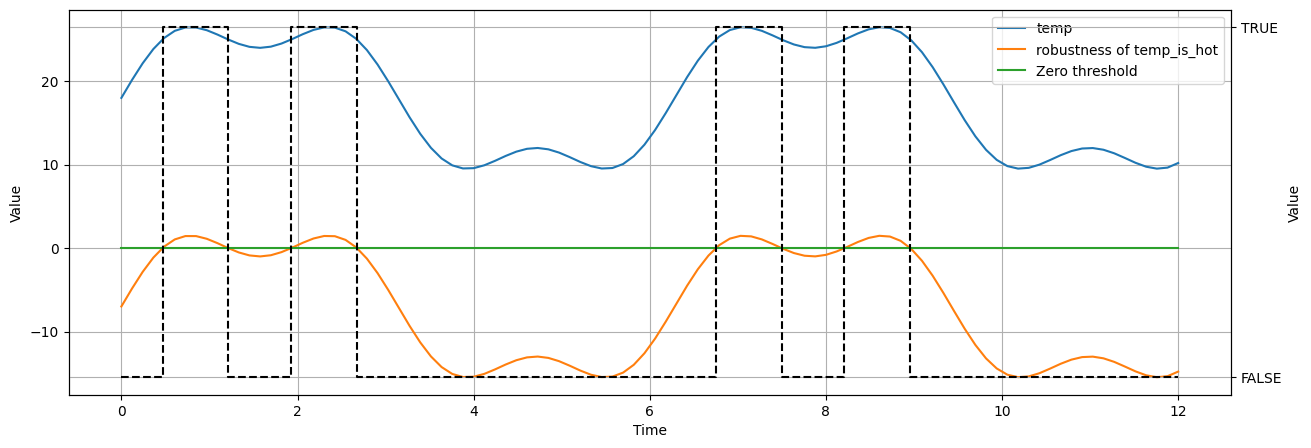

In [22]:
ax = Dtemp.plot_signal('temp')
rob_sig = Dtemp.get_rob_signal('temp_is_hot', 0, 12)
rob_sig.plot('robustness of temp_is_hot', ax=ax, plot_sat=True)
zero_sig = stl.Signal()
zero_sig.append_sample(0,0) # time=0, value=0 and derivative =0 (default)
zero_sig.end_time=12
zero_sig.plot(ax=ax, label= 'Zero threshold')

## Eventually

<Axes: xlabel='Time', ylabel='Value'>

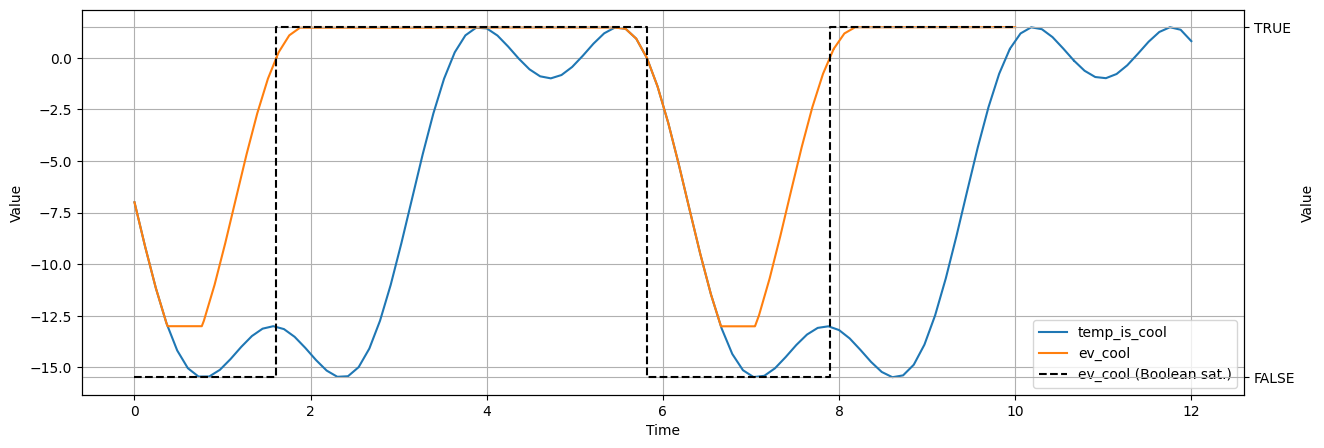

In [23]:
ax = Dtemp.plot_rob('temp_is_cool', 0,12)
Dtemp.plot_rob('ev_cool',0,10, ax=ax, plot_sat=True)

## Always 

<Axes: xlabel='Time', ylabel='Value'>

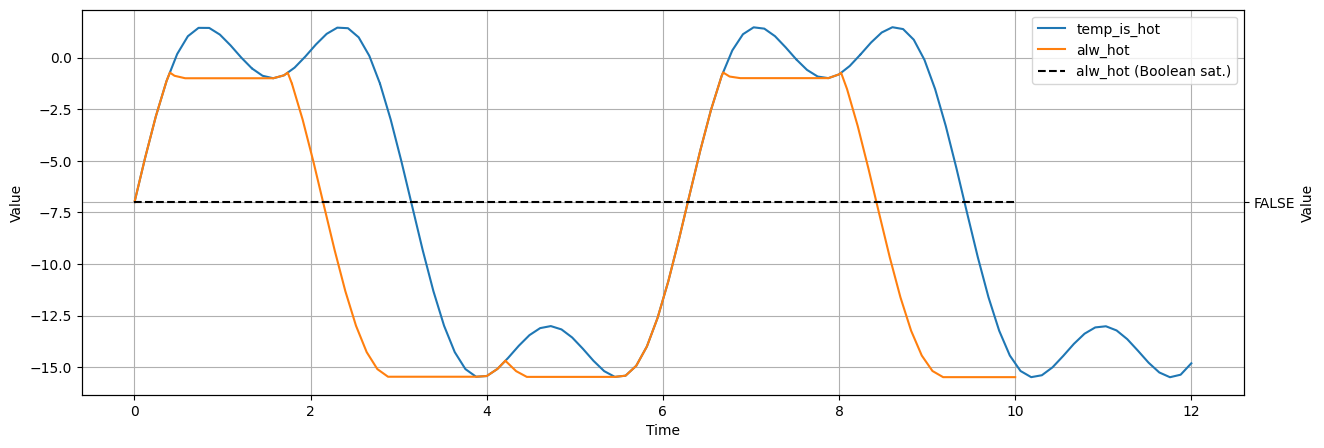

In [24]:
ax = Dtemp.plot_rob('temp_is_hot', 0,12)
Dtemp.plot_rob('alw_hot',0,10, ax=ax, plot_sat=True)

With `tau=1` and `hot=25`, the formula `alw_hot` is never true. We can try different parameter values.


<Axes: xlabel='Time', ylabel='Value'>

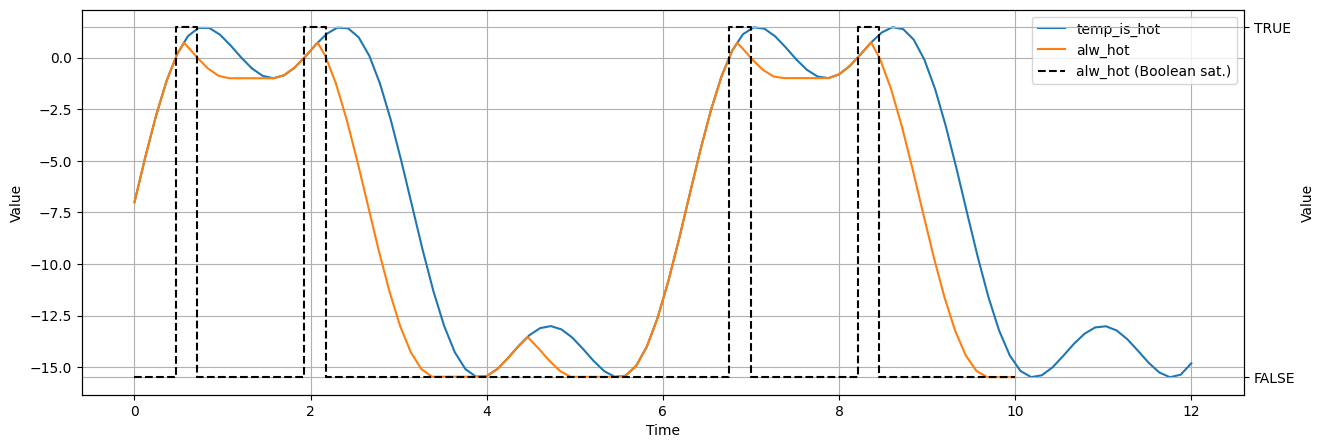

In [25]:
Dtemp.set_param('tau',0.5)
ax = Dtemp.plot_rob('temp_is_hot', 0,12)
Dtemp.plot_rob('alw_hot',0,10, ax=ax, plot_sat=True)

<Axes: xlabel='Time', ylabel='Value'>

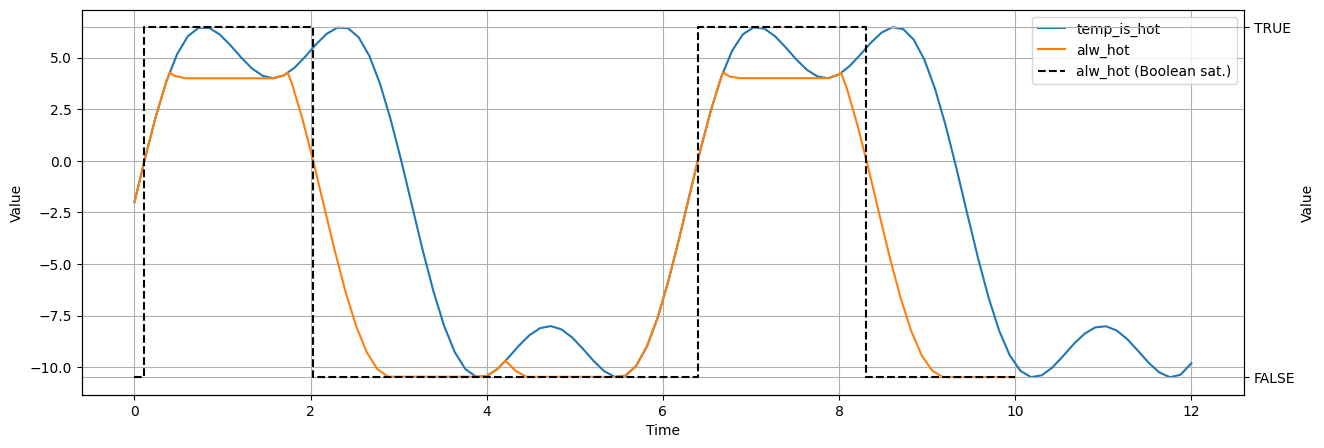

In [26]:
Dtemp.set_param('tau',1)
Dtemp.set_param('hot', 20)
ax = Dtemp.plot_rob('temp_is_hot', 0,12)
Dtemp.plot_rob('alw_hot',0,10, ax=ax, plot_sat=True)

In [27]:
Dtemp.set_param('hot', 25)
Dtemp.get_rob('phi')

-1.466170273888494

`phi` is evaluated as False. We can understand why by looking at `temp_is_hot` and `ev_cool` satisfaction.

<Axes: xlabel='Time', ylabel='Value'>

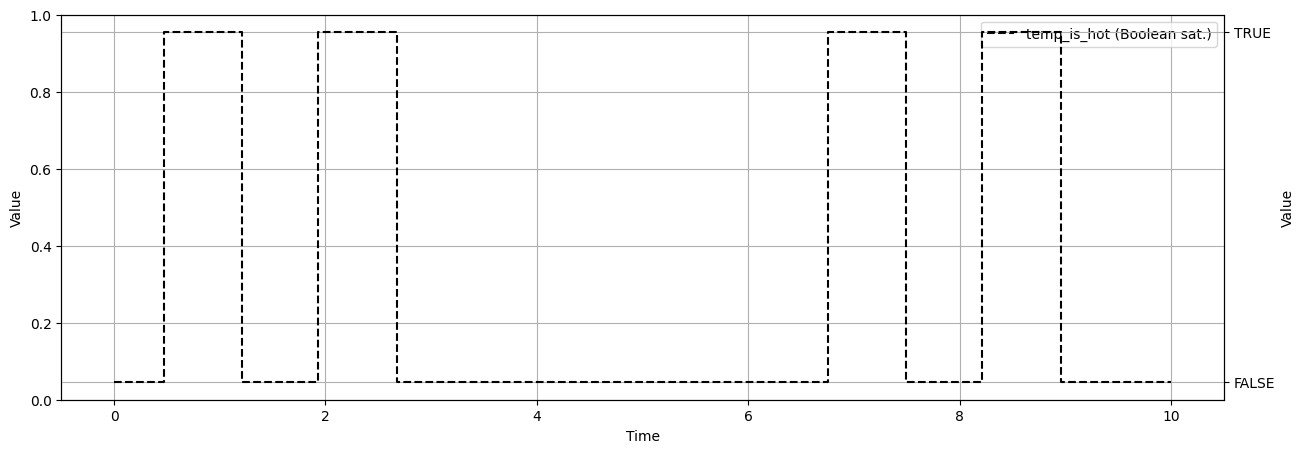

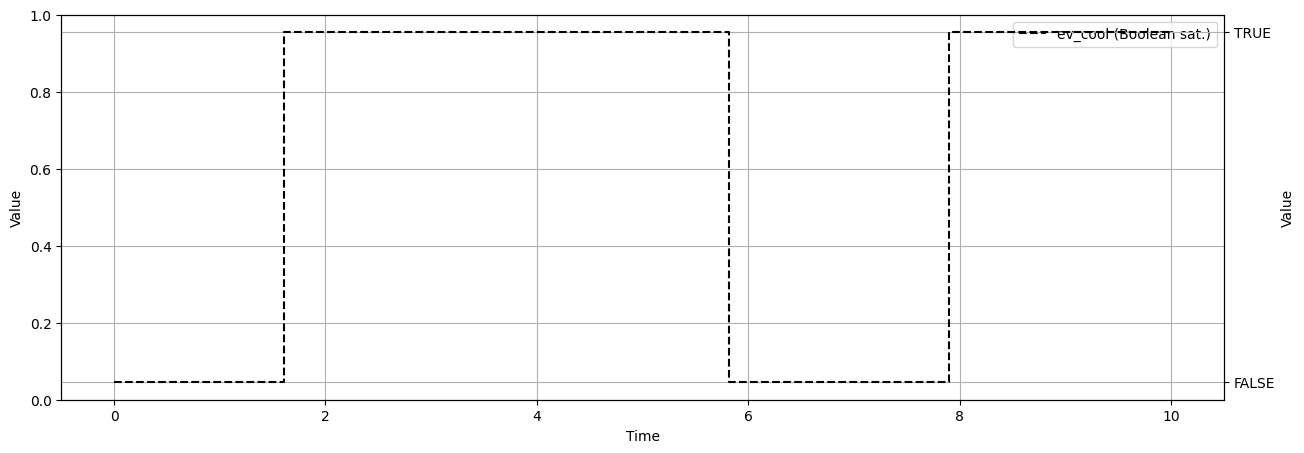

In [29]:
ax = Dtemp.plot_sat('temp_is_hot',0,10)
Dtemp.plot_sat('ev_cool',0,10)

At time t=1, `temp_is_hot` is true but `ev_cool` is not, which explains why `phi` is false. We can give more time to cool:

In [ ]:
Dtemp.set_param('tau_cool',4)
Dtemp.get_rob('phi')

`phi` is true, now. 

# Online Monitoring

"Online" monitoring refer to the process of providing satisfaction estimate of formulas over signals for which we don't have all the necessary data. For example, the formula `ev_[0, 2] temp_is_cool` needs 2 time units of data to be evaluated. By default, `get_rob()` in that case will extrapolate the necessary data. 

<Axes: xlabel='Time', ylabel='Value'>

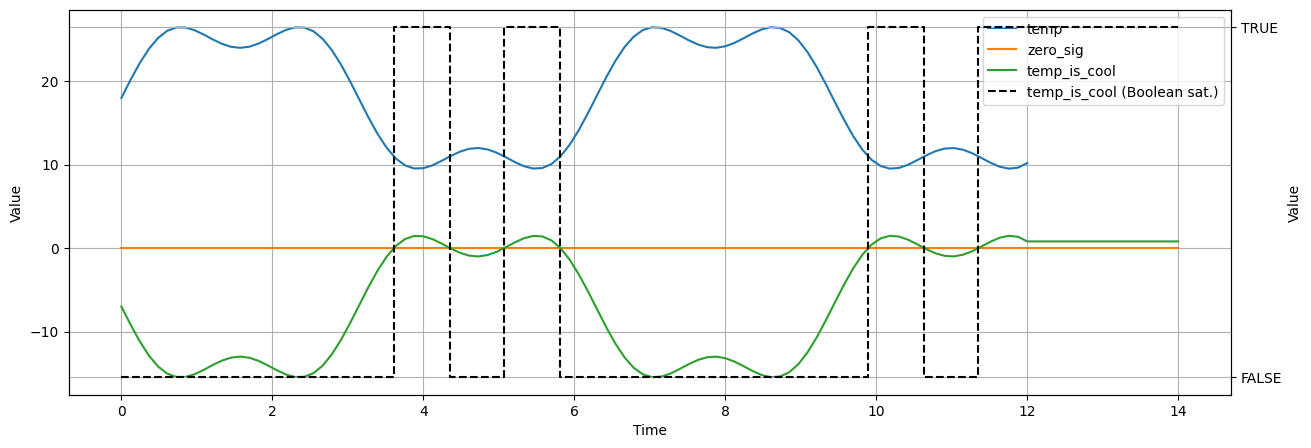

In [30]:
Dtemp.set_param('tau',0.5)
ax = Dtemp.plot_signal('temp')
zero_sig.end_time=14
zero_sig.plot('zero_sig', ax=ax)
Dtemp.plot_rob('temp_is_cool', 0,14, ax=ax, plot_sat=True) # we have data only until 12 
#Dtemp.plot_rob('alw_hot',0,12, ax=ax, plot_sat=True)

As a consequence, the property `alw_[0, 2] temp_is_cool`, which is intuitively never true, becomes true toward the end because of constant extrapolation.

<Axes: xlabel='Time', ylabel='Value'>

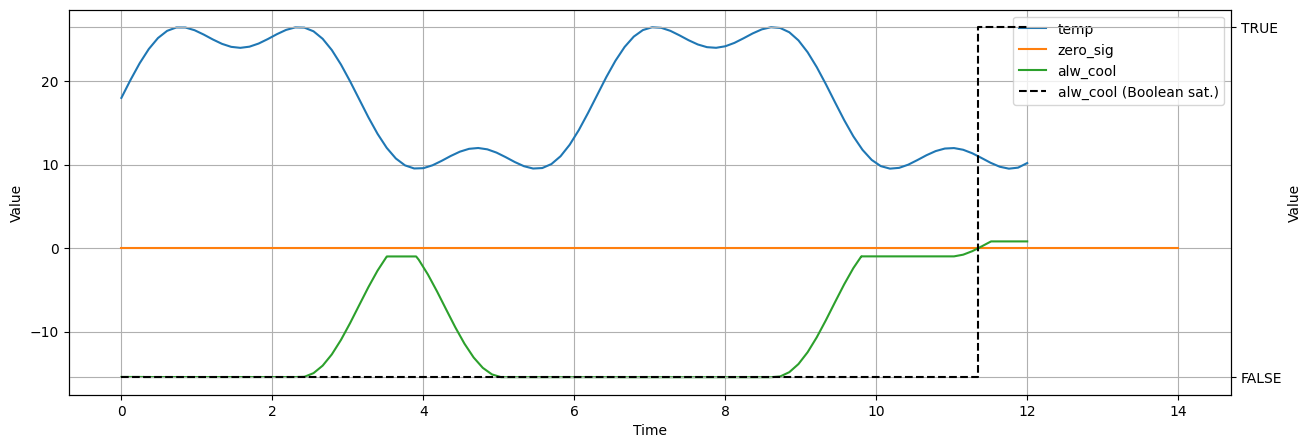

In [31]:
Dtemp.parse_string('alw_cool:= alw_[0,2] temp_is_cool') # adding a formula
ax = Dtemp.plot_signal('temp')
zero_sig.end_time=14
zero_sig.plot('zero_sig', ax=ax)
Dtemp.plot_rob('alw_cool', 0,12, ax=ax, plot_sat=True) 

To get a more conservative estimate, we use `get_online_rob("phi")` which returns three values: `[rob_estimate, rob_low, rob_up]`. They have the following characteristics:
- if the `phi` can be fully evaluated by the data, then all three values are equal to the actual robust satisfaction `rob` of the formula. On the example above, this is the case for atomic propositions, which are evaluated at time 0 by default.
- Otherwise, `[rob_estimate, rob_low, rob_up]` are respectively an estimate, a lower bound and an upper bound of `rob`. In the example above, `phi` cannot be evaluated because we have data up to time 3 and the formula requires data up to time `tau`, which is 5. However, stlrom computed that rob is between 3 and 10000, which means that we can already assert that the formula is satisfied (rob is positive.) 

In [ ]:
temp.set_BigM(30)

# Robustness of Equality

In [32]:
stl.Signal.set_Eps(0.01)

rob_eq = d2.get_rob_signal('mu_eq', 0, 10)

ax = osc_signal.plot(label='Oscillating signal');
ax.plot([0, osc_signal.end_time], [stl.Signal.get_Eps(), stl.Signal.get_Eps()], linestyle='--', color='black', label="± $\\varepsilon$")
ax.plot([0, osc_signal.end_time], [-stl.Signal.get_Eps(), -stl.Signal.get_Eps()], linestyle='--', color='black')
ax = rob_eq.plot(label='Robustness of mu_eq for oscillating signal', ax=ax);



NameError: name 'd2' is not defined

In [ ]:
d2 = stl.STLDriver()
d2.parse_string("""
    signal x
    mu_eq := x[t] == 0
    """)

d2.set_signals([osc_signal])
print(d2)

In [ ]:
stl.Signal.set_Eps(1e-12)

## Parsing Formulas

In [ ]:
d3 = stl.STLDriver()
d3.parse_string("""signal temp                
    param Tmax = 25, tau=2
    mu_temp := temp[t] < Tmax

    # Temperature should always be below Tmax
    phi_ev := ev[0, tau] (mu_temp)

    # If temperature is above Tmax, it should eventually be below Tmax within 2 seconds
    phi := alw[0, 8 ] ((not mu_temp) => phi_ev)
    """)

d3.set_signals([temp_signal])

In [ ]:
print(d3)

## Robustness of Top Formula

In [ ]:
tau=1
d3.set_param('tau', tau);d3.set_param('Tmax', 20);
d3.set_semantics('SPACE')
r_phi_ev = d3.get_rob_signal('phi_ev', 0, 12-tau)

ax = temp_signal.plot(label='Temperature signal');
r_phi_ev.plot(label='Robustness of ev[0,1](T<20)', ax=ax, plot_sat=True);

## Robustness Map

In [ ]:
r_phi, _, _ = d3.get_online_rob_signal('phi', 0, 6)
rob_map = d3.get_online_robustness_map('phi')
stl.plot_rob_map_widget(rob_map)